In [53]:
%pip install numpy matplotlib pandas
%pip install openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

# cntrl + / to add comment to a line of code
# numpy is a library for numerical computing in Python, it provides support for arrays and matrices, along with a collection of mathematical functions to operate on these data structures.
# matplotlib is a plotting library for Python, it provides a wide range of functions for creating static
# pandas is a library for data manipulation and analysis in Python, it provides data structures like DataFrame and Series, which are used for handling and analyzing structured data.
# %matplotlib inline is a magic command in Jupyter notebooks that allows you to display matplotlib plots directly in the notebook, rather than in a separate window.


In [55]:
def plot_growth(filepath, title):

    df = pd.read_excel(filepath)
    time = df['time'].to_numpy(dtype=float)
    od600 = df['OD600'].to_numpy(dtype=float)

    ln_od600 = np.log(od600)
    
    d1 = np.diff(ln_od600) / np.diff(time)
    
    time_mid = (time[:-1] + time[1:]) / 2
    d2 = np.diff(d1) / np.diff(time_mid)
    
    time_mid2 = (time_mid[:-1] + time_mid[1:]) / 2
    
    datasets = [
        (time,      od600,    '① Raw Growth Curve',  'OD600',             'steelblue'),
        (time,      ln_od600, '② ln(OD600)',          'ln(OD600)',         'darkorange'),
        (time_mid,  d1,       '③ First Derivative',   'd(ln OD600)/dt',    'seagreen'),
        (time_mid2, d2,       '④ Second Derivative',  'd²(ln OD600)/dt²',  'crimson'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)

    for idx, (ax, dataset) in enumerate(zip(axes, datasets)):

        x, y, subtitle, ylabel, color = dataset

        ax.plot(
            x, y,
            marker='o', color=color, linewidth=2,
            markersize=6, markerfacecolor='white',
            markeredgewidth=1.8, zorder=2
        )

        for i, (xi, yi) in enumerate(zip(x, y)):
            if idx == 2:
                # d1: midpoint between time[i] and time[i+1]
                label = f'({time[i]:.0f}-{time[i+1]:.0f} h, {yi:.2f})'
            elif idx == 3:
                # d2: spans two original intervals, so time[i] to time[i+2]
                label = f'({time[i]:.0f}-{time[i+2]:.0f} h, {yi:.2f})'
            else:
                label = f'({xi:.0f} h, {yi:.2f})'

            ax.annotate(
                label,
                xy=(xi, yi),
                textcoords='offset points',
                xytext=(0, 8),
                fontsize=9, ha='center',
                color='#555555', zorder=3
            )

        if idx >= 2:
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

        if idx == 2:
            ax.set_xlim(time_mid[0] - 0.5, time_mid[-1] + 0.5)
        elif idx == 3:
            ax.set_xlim(time_mid2[0] - 0.5, time_mid2[-1] + 0.5)

        ax.set_title(subtitle, fontsize=11, fontweight='bold', pad=8)
        ax.set_xlabel('Time (h)', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.tick_params(labelsize=8)
        ax.grid(True, linestyle='--', alpha=0.4, zorder=1)

    plt.tight_layout()
    plt.show()

## Control

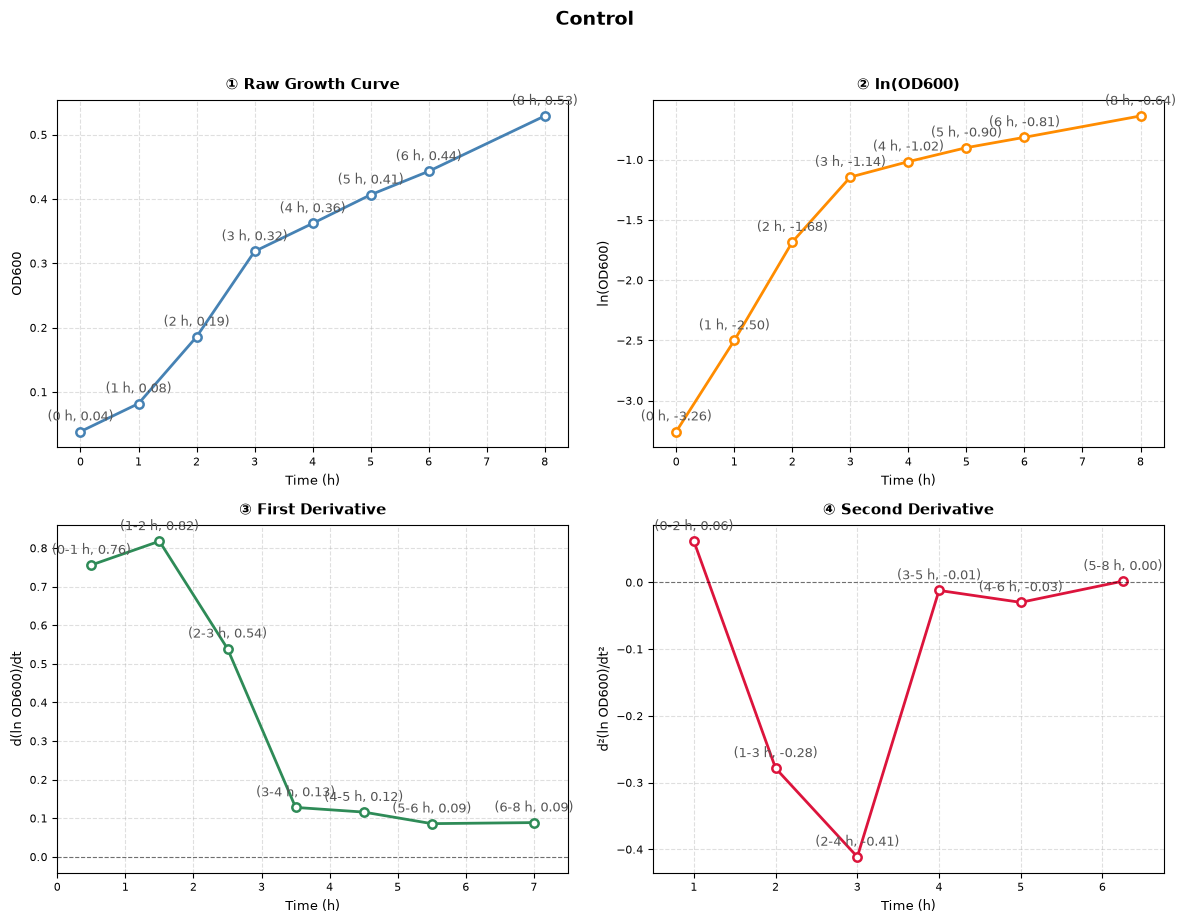

In [56]:
plot_growth('Control_growthcurveraw.xlsx', 'Control')

## 2.5 mg/L

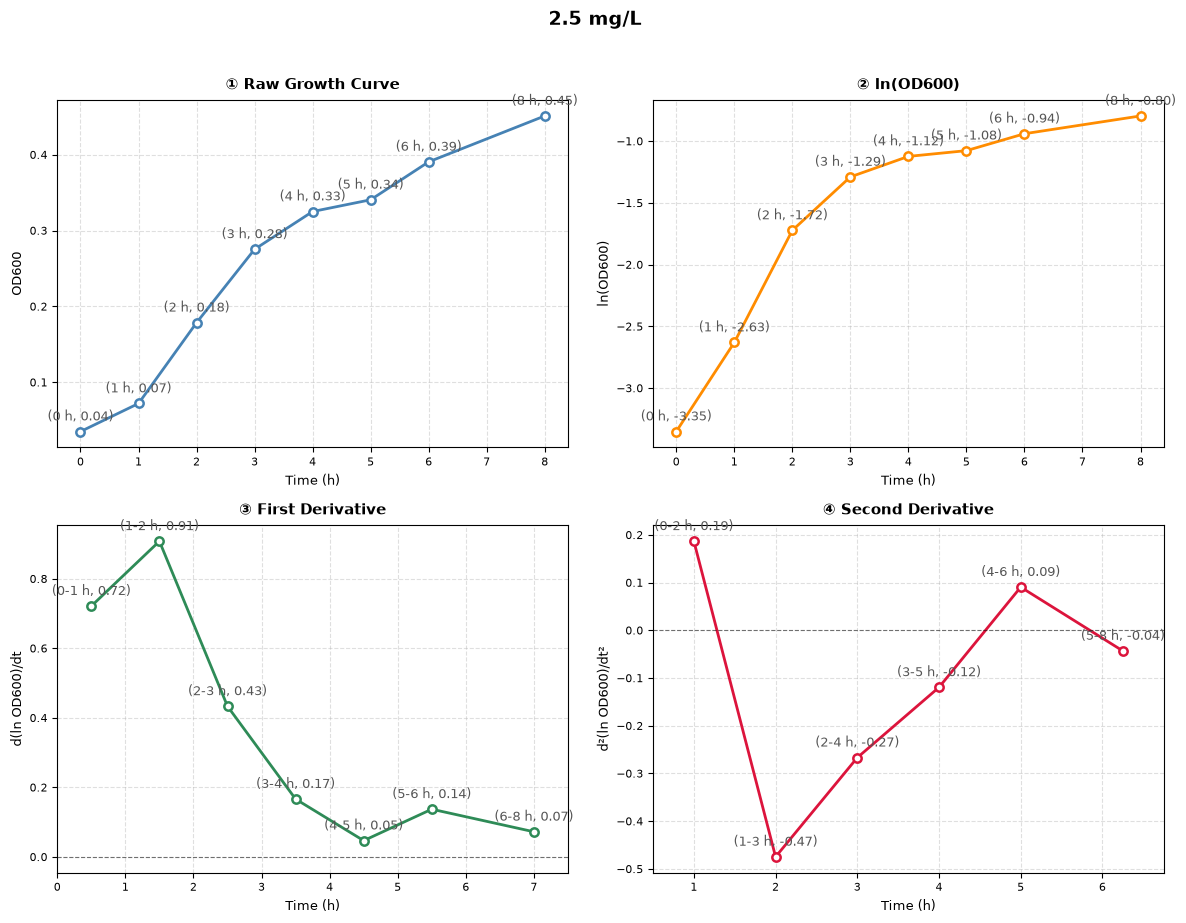

In [57]:
plot_growth('2.5mgl_growthcurveraw.xlsx', '2.5 mg/L')

## 5 mg/L

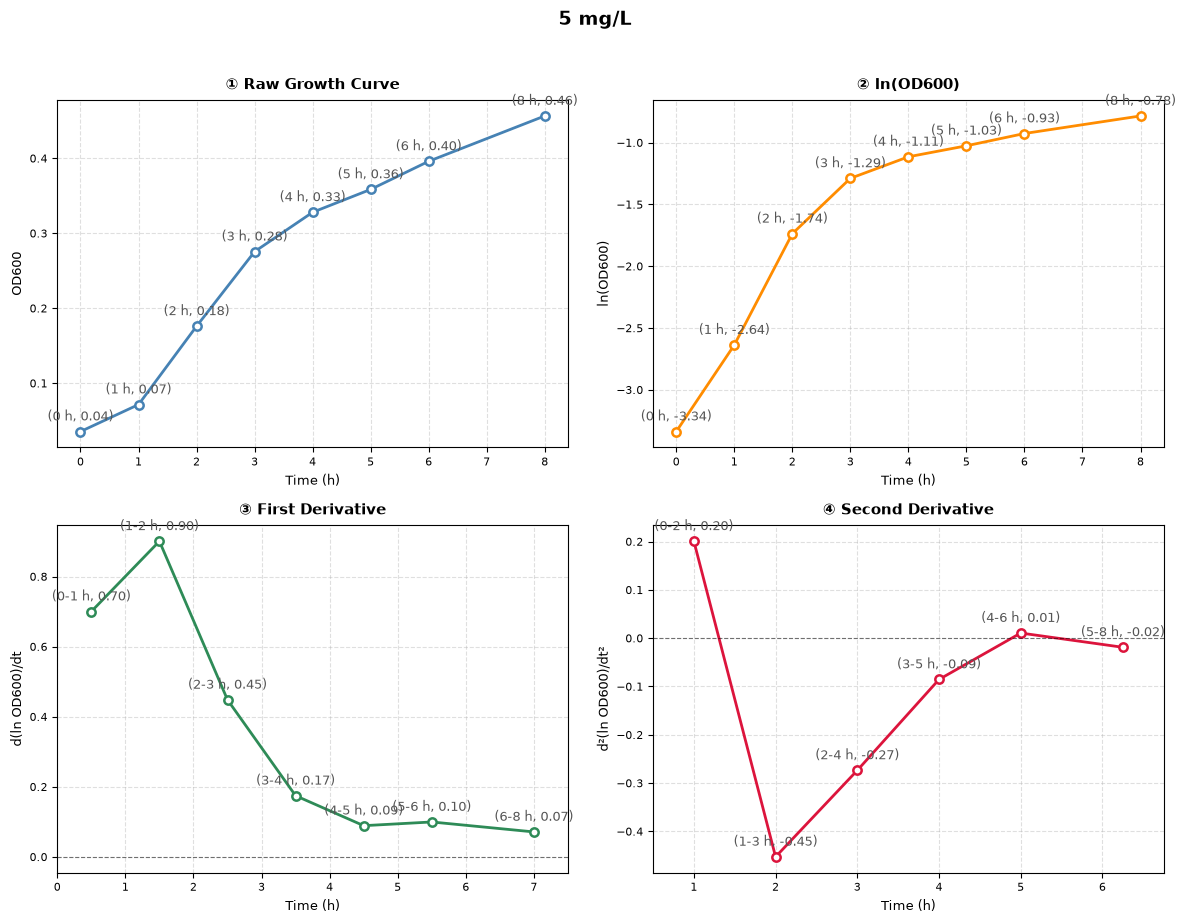

In [58]:
plot_growth('5mgl_growthcurveraw.xlsx', '5 mg/L')

## 10 mg/L

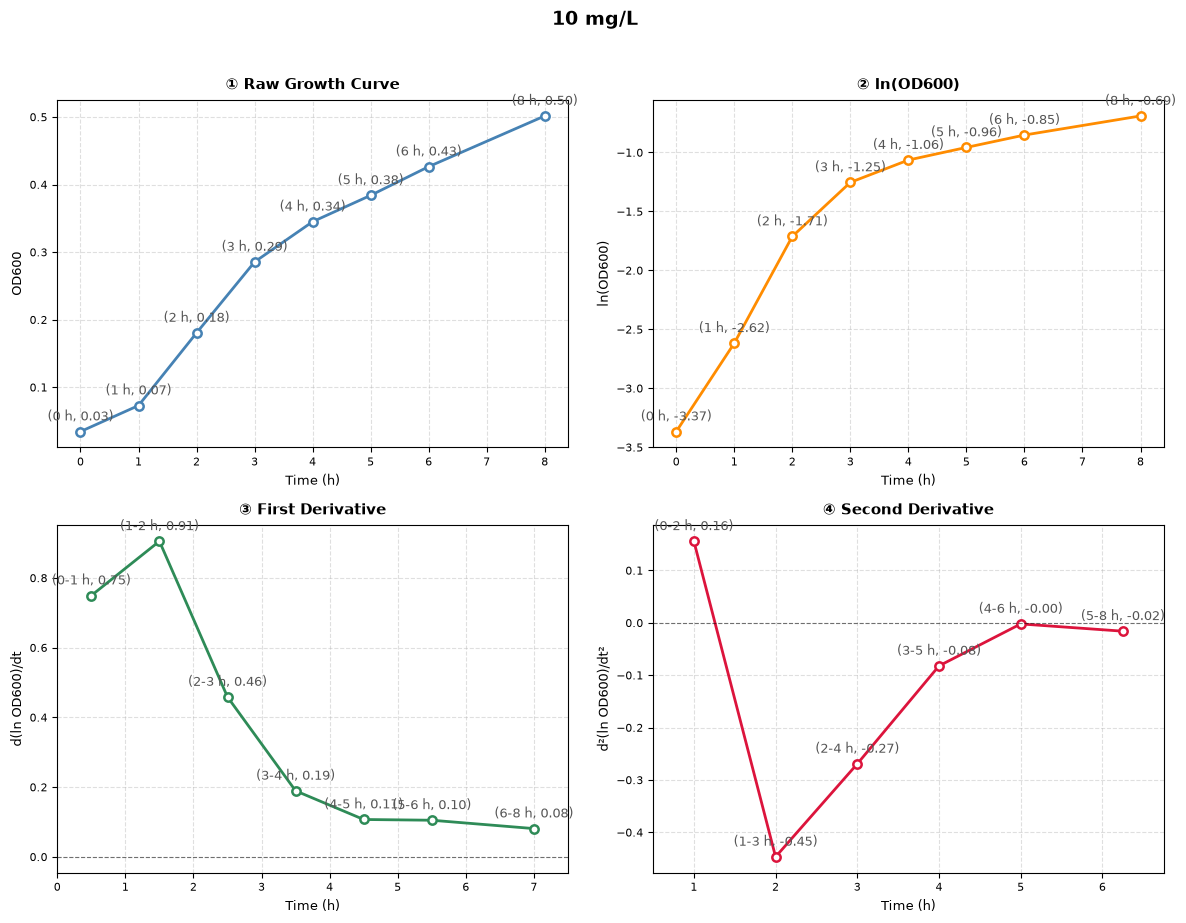

In [59]:
plot_growth('10mgl_growthcurveraw.xlsx', '10 mg/L')

## 20 mg/L

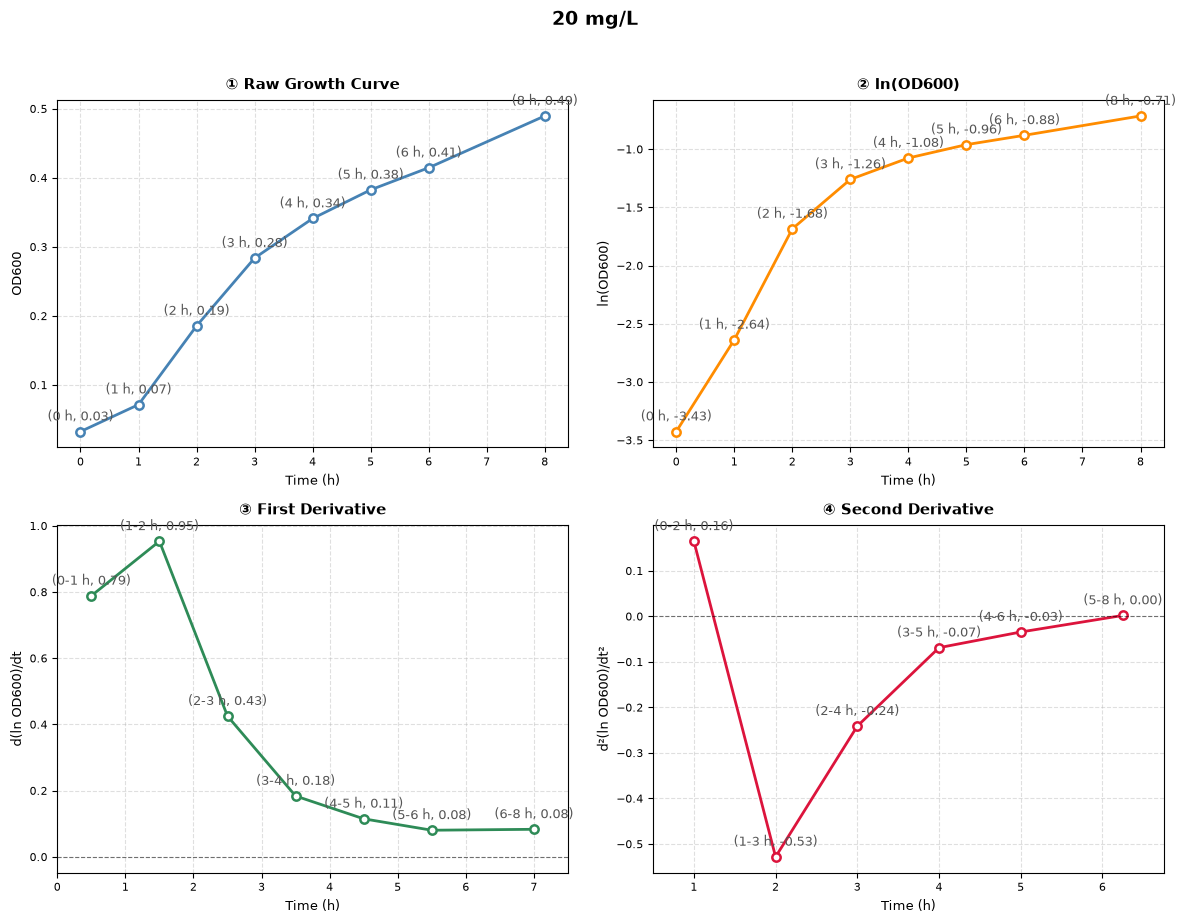

In [60]:
plot_growth('20mgl_growthcurveraw.xlsx', '20 mg/L')

## 40 mg/L

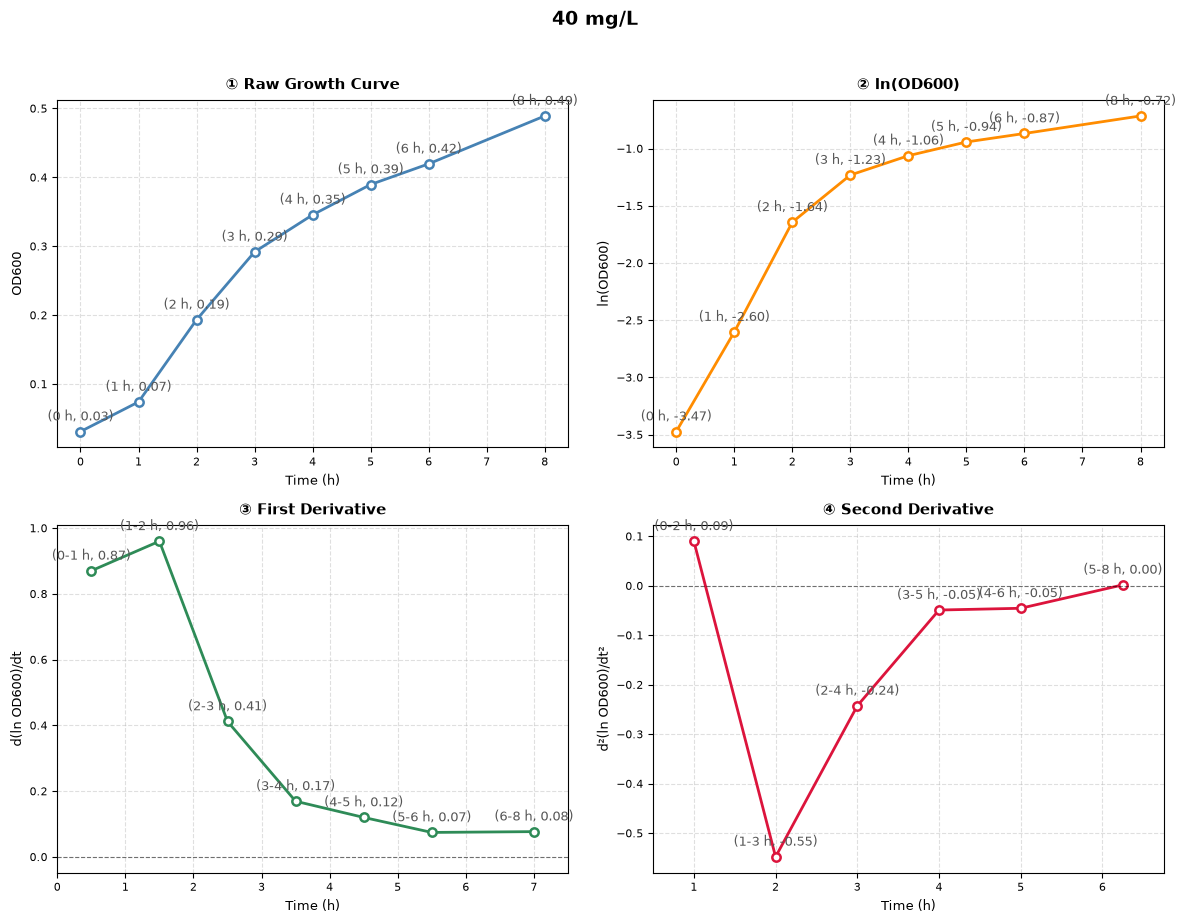

In [61]:
plot_growth('40mgl_growthcurveraw.xlsx', '40 mg/L')

## 80 mg/L

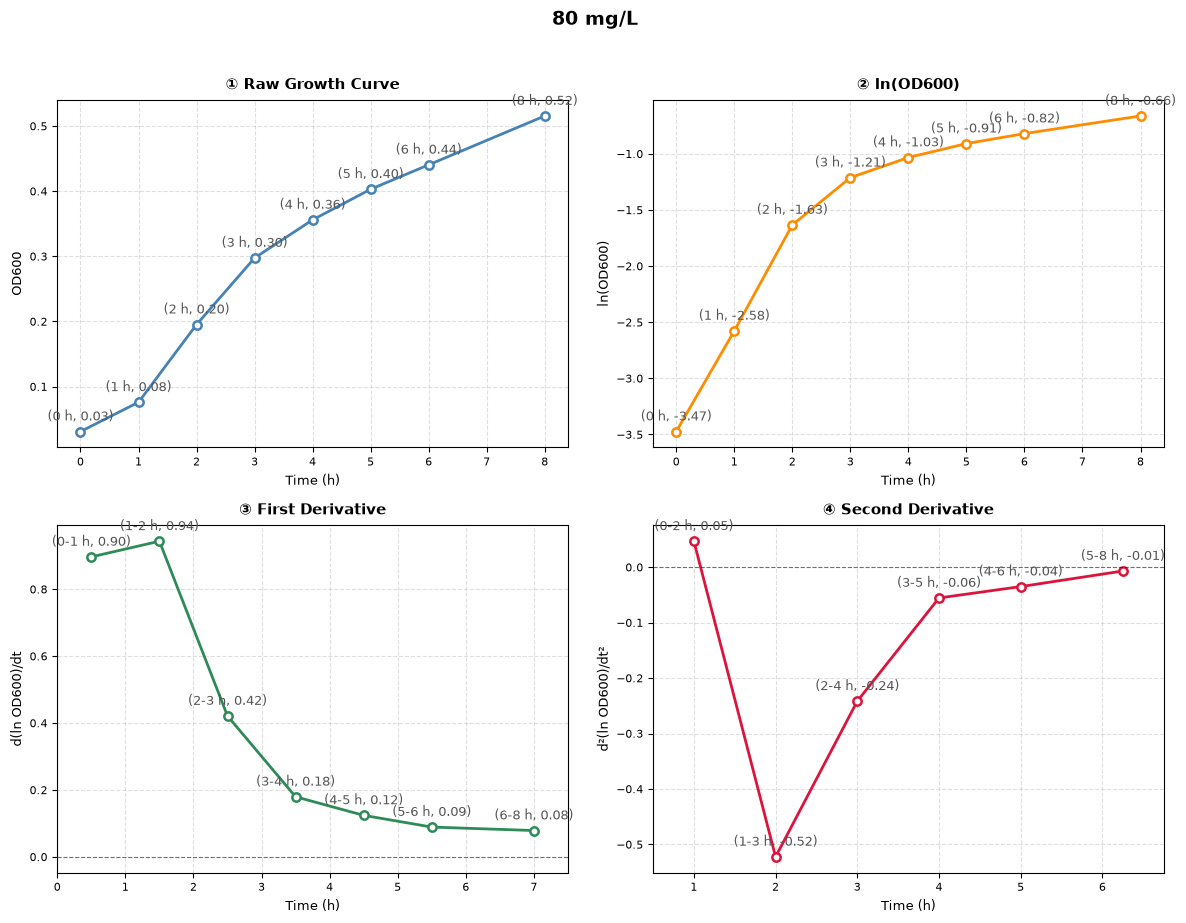

In [62]:
plot_growth('80mgl_growthcurveraw.xlsx', '80 mg/L')

## 160 mg/L

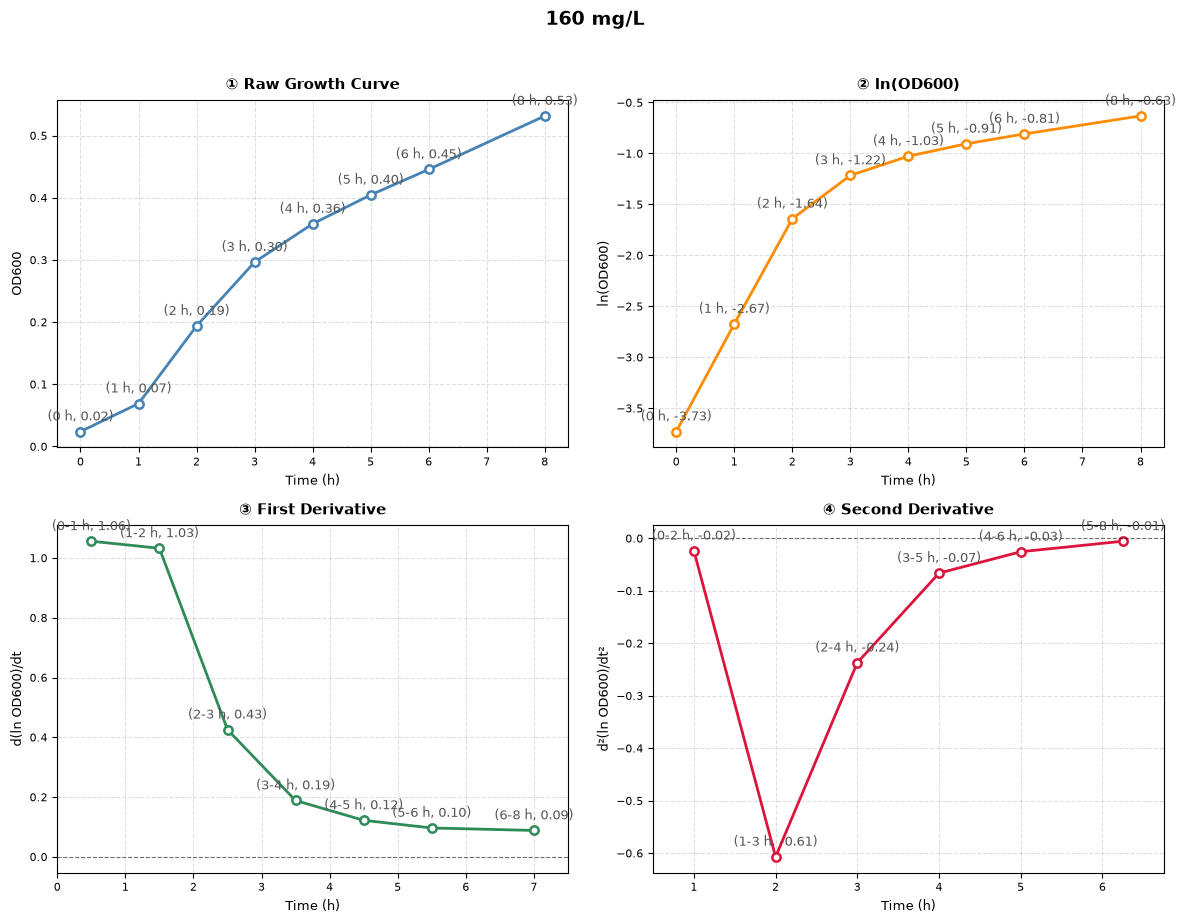

In [63]:
plot_growth('160mgl_growthcurveraw.xlsx', '160 mg/L')

## 320 mg/L

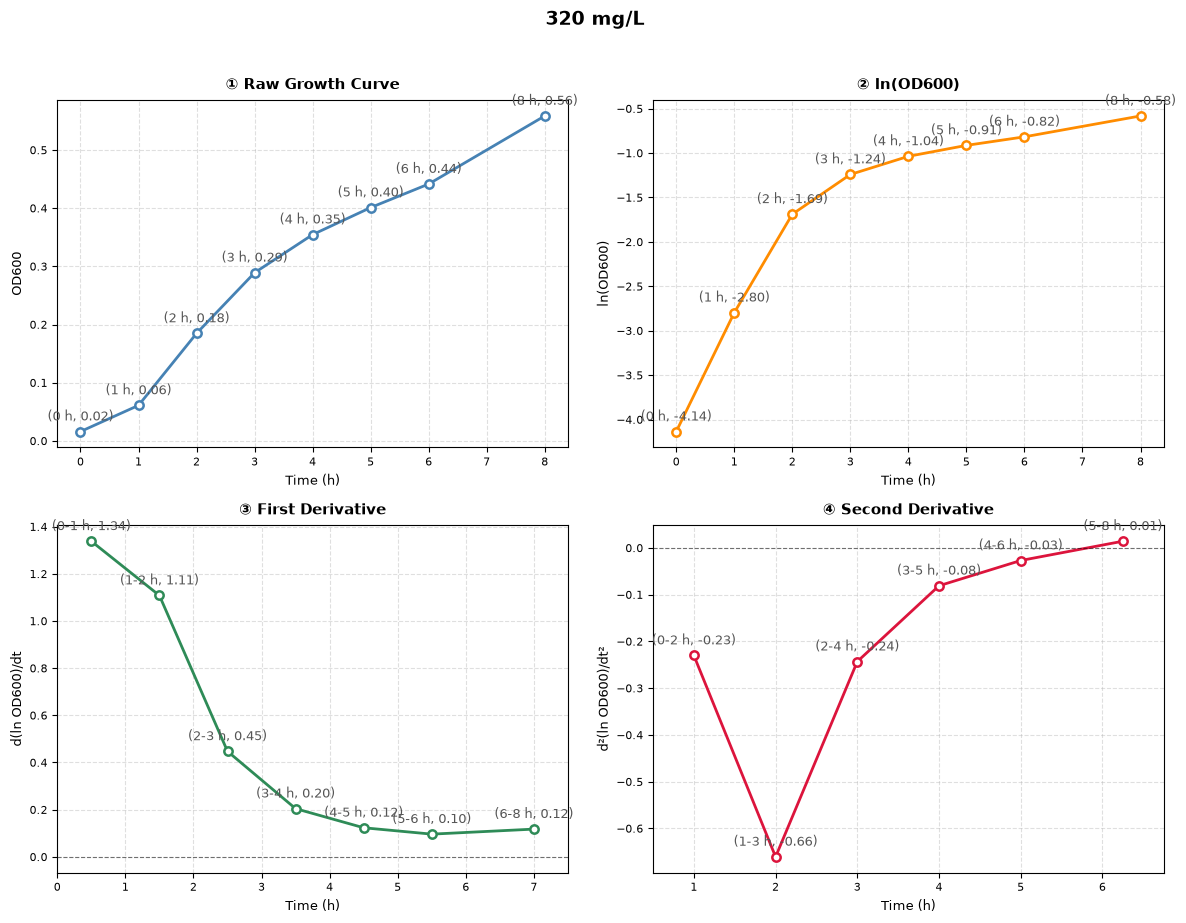

In [64]:
plot_growth('320mgl_growthcurveraw.xlsx', '320 mg/L')

In [65]:
import os

plot_dir = 'growth_plots'
data_dir = 'derivative_data'
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)

samples = [
    ('Control_growthcurveraw.xlsx',  'Control'),
    ('2.5mgl_growthcurveraw.xlsx',   '2.5 mg/L'),
    ('5mgl_growthcurveraw.xlsx',     '5 mg/L'),
    ('10mgl_growthcurveraw.xlsx',    '10 mg/L'),
    ('20mgl_growthcurveraw.xlsx',    '20 mg/L'),
    ('40mgl_growthcurveraw.xlsx',    '40 mg/L'),
    ('80mgl_growthcurveraw.xlsx',    '80 mg/L'),
    ('160mgl_growthcurveraw.xlsx',   '160 mg/L'),
    ('320mgl_growthcurveraw.xlsx',   '320 mg/L'),
]

def save_growth(filepath, title):
    df = pd.read_excel(filepath)
    time = df['time'].to_numpy(dtype=float)
    od600 = df['OD600'].to_numpy(dtype=float)

    ln_od600 = np.log(od600)

    time_mid = (time[:-1] + time[1:]) / 2
    d1 = np.diff(ln_od600) / np.diff(time)

    time_mid2 = (time_mid[:-1] + time_mid[1:]) / 2
    d2 = np.diff(d1) / np.diff(time_mid)

    # =========================
    # Save Derivative Data
    # =========================
    safe_title = title.replace('/', '_').replace(' ', '_')

    d1_df = pd.DataFrame({
        'interval':  [f'{time[i]:.0f}-{time[i+1]:.0f}' for i in range(len(d1))],
        'time_mid':  time_mid,
        'd(ln OD600)/dt': d1,
    })
    d1_df.to_excel(os.path.join(data_dir, f'{safe_title}_d1.xlsx'), index=False)

    d2_df = pd.DataFrame({
        'interval':  [f'{time_mid[i]:.1f}-{time_mid[i+1]:.1f}' for i in range(len(d2))],
        'time_mid2': time_mid2,
        'd2(ln OD600)/dt2': d2,
    })
    d2_df.to_excel(os.path.join(data_dir, f'{safe_title}_d2.xlsx'), index=False)

    # =========================
    # Plot
    # =========================
    datasets = [
        (time,      od600,    '① Raw Growth Curve',  'OD600',             'steelblue'),
        (time,      ln_od600, '② ln(OD600)',          'ln(OD600)',         'darkorange'),
        (time_mid,  d1,       '③ First Derivative',   'd(ln OD600)/dt',    'seagreen'),
        (time_mid2, d2,       '④ Second Derivative',  'd²(ln OD600)/dt²',  'crimson'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)

    for idx, (ax, dataset) in enumerate(zip(axes, datasets)):

        x, y, subtitle, ylabel, color = dataset

        ax.plot(
            x, y,
            marker='o', color=color, linewidth=2,
            markersize=6, markerfacecolor='white',
            markeredgewidth=1.8, zorder=2
        )

        for i, (xi, yi) in enumerate(zip(x, y)):
            if idx == 2:
                label = f'({time[i]:.0f}-{time[i+1]:.0f} h, {yi:.2f})'
            elif idx == 3:
                label = f'({time_mid[i]:.1f}-{time_mid[i+1]:.1f} h, {yi:.2f})'
            else:
                label = f'({xi:.0f} h, {yi:.2f})'

            ax.annotate(
                label,
                xy=(xi, yi),
                textcoords='offset points',
                xytext=(0, 10),
                fontsize=9,
                ha='center',
                color='#555555',
                zorder=3
            )

        if idx >= 2:
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

        if idx == 2:
            ax.set_xlim(time_mid[0] - 0.5, time_mid[-1] + 0.5)
        elif idx == 3:
            ax.set_xlim(time_mid2[0] - 0.5, time_mid2[-1] + 0.5)

        ax.set_title(subtitle, fontsize=11, fontweight='bold', pad=8)
        ax.set_xlabel('Time (hours)', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.tick_params(labelsize=8)
        ax.grid(True, linestyle='--', alpha=0.4, zorder=1)

    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'{safe_title}.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f'Saved plot + derivatives: {safe_title}')

for filepath, title in samples:
    save_growth(filepath, title)

print('Done.')

Saved plot + derivatives: Control
Saved plot + derivatives: 2.5_mg_L
Saved plot + derivatives: 5_mg_L
Saved plot + derivatives: 10_mg_L
Saved plot + derivatives: 20_mg_L
Saved plot + derivatives: 40_mg_L
Saved plot + derivatives: 80_mg_L
Saved plot + derivatives: 160_mg_L
Saved plot + derivatives: 320_mg_L
Done.
